# Ev_4

In [67]:
# 1. Identificación y justificación de técnicas de tratamiento:
# • Expliquen cómo el tratamiento de datos faltantes asegura la integridad de los datos para su posterior uso en algoritmos de
# machine learning.
# • Presenten ejemplos de cómo la técnica seleccionada afectó positivamente el conjunto de datos procesado.
# 2. Técnicas empleadas para la normalización y estandarización con su justificación:
# • Proporcionen ejemplos de cómo el escalamiento estandarizó las variables y permitió un desempeño sin errores de los
# algoritmos.
# • Presenten visualizaciones (antes y después del escalamiento) que demuestren la transformación de los datos.
# 3. Técnicas de codificación:
# • Detallen las técnicas empleadas (Label Encoding, One-Hot Encoding, Ordinal Encoding y categorical encoding).
# • Justifiquen por qué se seleccionó una técnica específica según las características de las variables categóricas y el modelo.
# 4. Proceso de creación de nuevas variables:
# • Expliquen las técnicas aplicadas (agregaciones, transformaciones matemáticas, interacciones entre variables, etc.).
# • Justifiquen cómo estas nuevas variables aportan valor al análisis y mejoran el rendimiento del modelo.


In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [69]:
df = pd.read_csv("bank-additional-full.csv", sep=';')

In [70]:
df.shape

(41188, 21)

In [71]:
df.head(2)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Informacion de las variables

In [72]:
# 1 - edad (numerico)
# 2 - trabajo: tipo de trabajo (categorico: "administrador", "obrero", "empresario", "empleado domestico",
#     "gerente", "jubilado", "autonomo", "servicios", "estudiante", "tecnico", "desempleado", "desconocido")
# 3 - estado civil: estado civil (categorico: "divorciado", "casado", "soltero", "desconocido";
#     nota: "divorciado" significa divorciado o viudo)
# 4 - educacion (categorico: "basico.4a", "basico.6a", "basico.9a", "bachillerato", "analfabeto",
#     "curso profesional", "titulo universitario", "desconocido")
# 5 - mora: tiene credito en mora? (categorico: "no", "si­", "desconocido")
# 6 - vivienda: ¿tiene prestamo para vivienda? (categorico: "no", "si­", "desconocido")
# 7 - prestamo: ¿tiene prestamo personal? (categorico: "no", "si­", "desconocido")

# Relacionado con el ultimo contacto de la campaña actual:
# 8 - contacto: tipo de comunicacion del contacto (categorico: "celular", "telefono")
# 9 - mes: mes del año del ultimo contacto (categorico: "ene", "feb", "mar", ..., "nov", "dic")
# 10 - dia_de_la_semana: di­a de la semana del ultimo contacto (categorico: "mon", "tue", "wed", "thu", "fri")
# 11 - duracion: duracion del ultimo contacto, en segundos (numerico).
# Nota importante: este atributo afecta en gran medida el objetivo de salida
# (p. ej., si duracion=0 entonces y="no"). Sin embargo, la duracion no se conoce antes de que se realice una llamada. Ademas,
# despues del final de la llamada, obviamente se conoce y. Por lo tanto, esta entrada solo se debe incluir con fines de referencia
# y se debe descartar si la intencion es tener un modelo predictivo realista.

# Otros atributos:
# 12 - campaña: numero de contactos realizados durante esta campaña y para este cliente (numerico, incluye el ultimo contacto)
# 13 - pdays: numero de di­as transcurridos desde que el cliente fue contactado por ultima vez de una campaña anterior (numerico; 999 significa que el cliente no fue contactado previamente)
# 14 - anterior: numero de contactos realizados antes de esta campaña y para este cliente (numerico)
# 15 - poutcome: resultado de la campaña de marketing anterior (categorico: "fracaso", "inexistente", "exito")

# Atributos de contexto social y economico
# 16 - emp.var.rate: tasa de variacion del empleo - indicador trimestral (numerico)
# 17 - cons.price.idx: indice de precios al consumidor - indicador mensual (numerico)
# 18 - cons.conf.idx: i­ndice de confianza del consumidor - indicador mensual (numerico)
# 19 - euribor3m: tasa del euribor a 3 meses - indicador diario (numerico)
# 20 - nr.employed: numero de empleados

## Limpieza de variables no relevantes
* duracion

Como se menciona en la descripcion de las variables, la duracion es un dato que solo se obtiene al finalizar la llamada y al finalizarla ya se sabe el resultado de "y", por lo que es inutil predecir en base a ese dato ya que no se tendria la duracion, evitando el Data Leakage

In [73]:
df = df.drop(columns=['duration'])

## Busqueda de MV (valores nulos o bajo otros terminos como "unknow")
Lectura del dataSet clasificando MV como Nan

Listado de los valores unicos en cada variable
<br>Util para detectar valores MV que no estan definidos como Nan pero si bajo otros terminos como unknown

In [74]:
lista = df.columns.tolist()

for i in lista:
  print(i)
  print(df[i].unique())

age
[56 57 37 40 45 59 41 24 25 29 35 54 46 50 39 30 55 49 34 52 58 32 38 44
 42 60 53 47 51 48 33 31 43 36 28 27 26 22 23 20 21 61 19 18 70 66 76 67
 73 88 95 77 68 75 63 80 62 65 72 82 64 71 69 78 85 79 83 81 74 17 87 91
 86 98 94 84 92 89]
job
['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']
marital
['married' 'single' 'divorced' 'unknown']
education
['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']
default
['no' 'unknown' 'yes']
housing
['no' 'yes' 'unknown']
loan
['no' 'yes' 'unknown']
contact
['telephone' 'cellular']
month
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']
day_of_week
['mon' 'tue' 'wed' 'thu' 'fri']
campaign
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 19 18 23 14 22 25 16 17 15 20 56
 39 35 42 28 26 27 32 21 24 29 31 30 41 37 40 33 34 43]
pdays
[999   6   4   3   5   1   0  10   7   8   9  11 

Luego de encontrar valores MV, al ser solo unknown, leemos de nuevo el dataSet marcando los unknown como nan para luego limpiar los datos

In [75]:
df = pd.read_csv("bank-additional-full.csv", sep=';', na_values='unknown')
df = df.drop(columns=['duration']) # Recordar que se elimina duracion para evitar Data Leakage

In [76]:
# Ciclo for para listar MV y su porcentaje en cada variable
for i in range(df.shape[1]):
  n_miss = int(df.iloc[:, i].isnull().sum())
  perc = round(n_miss / df.shape[0] * 100,1)
  if n_miss > 0: # Trae solo las variables con nulos, evita mostrar muchos datos inecesarios
    t = "{0} - {1}  =  Missing: {2} ({3}%)".format(i, df.columns[i], n_miss, perc)
    print(t)

1 - job  =  Missing: 330 (0.8%)
2 - marital  =  Missing: 80 (0.2%)
3 - education  =  Missing: 1731 (4.2%)
4 - default  =  Missing: 8597 (20.9%)
5 - housing  =  Missing: 990 (2.4%)
6 - loan  =  Missing: 990 (2.4%)


Ya que default y education son variables significativas porcentualmente en MV, mientras que job, marital, housing y loan, son MV porcentualmente muy bajos, como equipo consideramos analizar el tipo de MV que es education y default, para saber como imputarlos, y las demas variables imputarlas de forma simple ya que no generaran un sesgo significativo en la data

## Clasificacion tipo de MV
* education(Nivel Educativo)
<br>Resultado = MAR

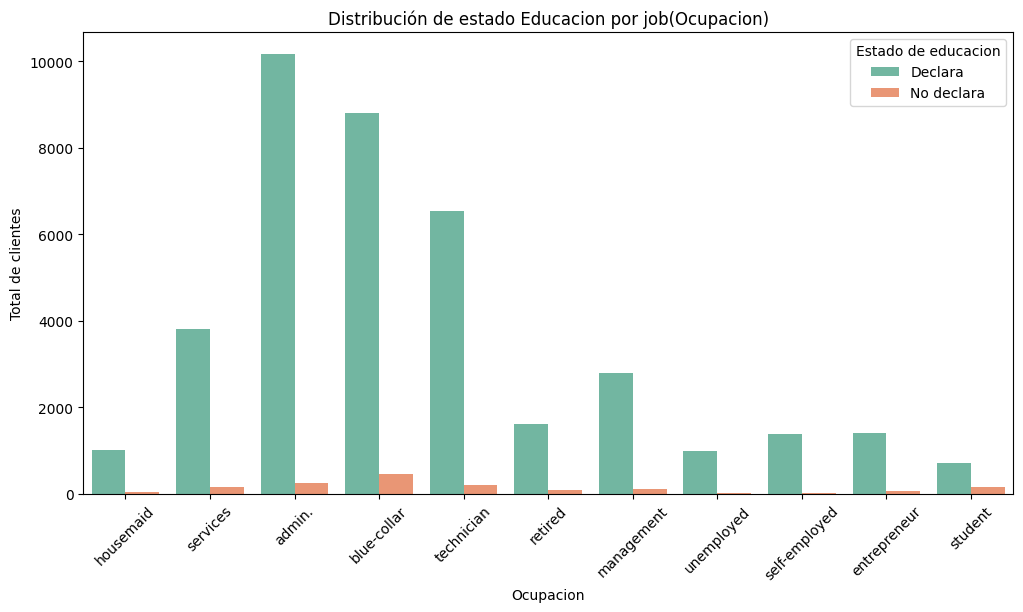

In [77]:
# se crea esta nueva columna solo para no cambiar el valor NaN a unknown o similar
df_analisis = df.copy()
df_analisis['Estado'] = df_analisis['education'].apply(lambda x: 'No declara' if True == pd.isna(x) else 'Declara') # Variable creada para separar los datos entre datos MV y no MV

plt.figure(figsize=(12, 6))
sns.countplot(data=df_analisis,
              x=f'job',
              hue='Estado',
              palette='Set2')

plt.title(f'Distribución de estado Educacion por job(Ocupacion)')
plt.ylabel("Total de clientes")
plt.xlabel(f"Ocupacion")
plt.xticks(rotation=45)
plt.legend(title='Estado de educacion')
plt.show()

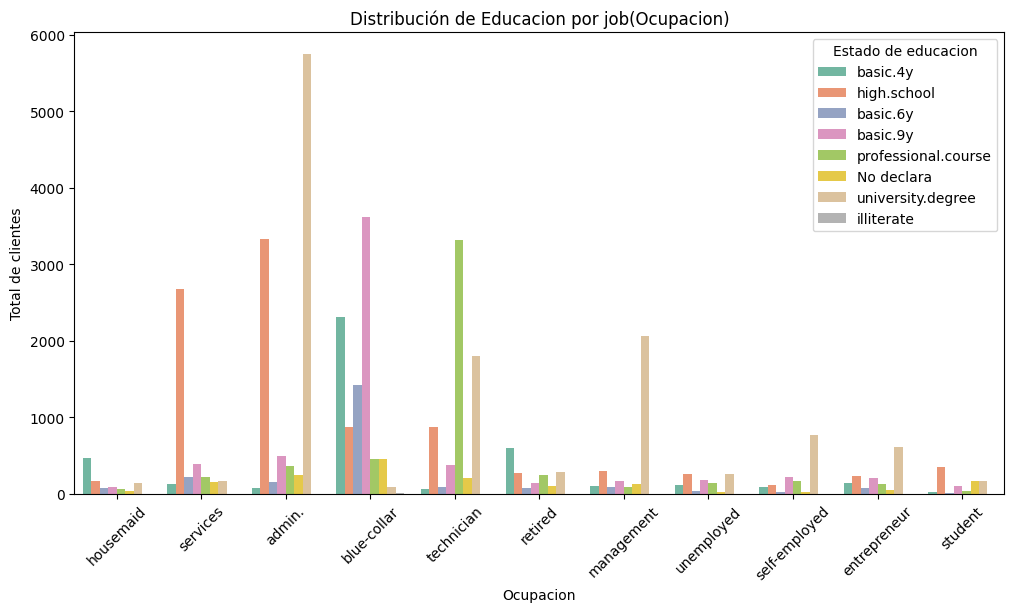

In [78]:
df_analisis = df.copy()
df_analisis['Estado'] = df_analisis['education'].apply(lambda x: 'No declara' if True == pd.isna(x) else x) # Variable creada para separar los datos entre datos MV y no MV

plt.figure(figsize=(12, 6))
sns.countplot(data=df_analisis,
              x=f'job',
              hue='Estado',
              palette='Set2')

plt.title(f'Distribución de Educacion por job(Ocupacion)')
plt.ylabel("Total de clientes")
plt.xlabel(f"Ocupacion")
plt.xticks(rotation=45)
plt.legend(title='Estado de educacion')
plt.show()

En base a que existe un nivel educativo en cada ocupacion de la variable "job", se puede deducir que la variable es de tipo MAR al tener una relacion con job, donde se asume que el cliente no ingreso su nivel educativo por verguenza a que este le de problemas en el banco, esto se puede suponer considerando que la mayor frecuencia esta marcada en blue-collar, como la clase obrera

## Clasificacion tipo de MV
* default(Morosidad)
<br>Resultado = MAR

Analisis preventivo

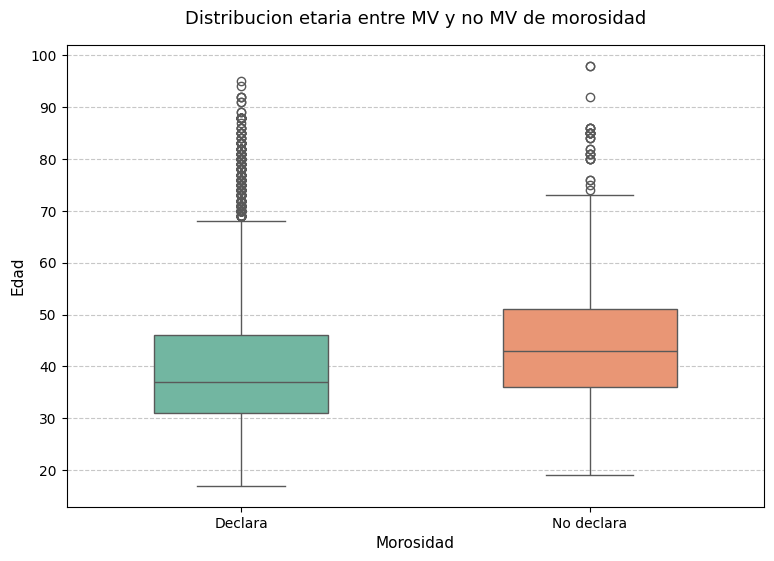

In [79]:
df_analisis = df.copy()
df_analisis['Estado'] = df_analisis['default'].apply(lambda x: 'No declara' if True == pd.isna(x) else 'Declara')

plt.figure(figsize=(9, 6))
sns.boxplot(data=df_analisis,
            x='Estado',
            y='age',
            palette='Set2',
            hue='Estado',
            width=0.5)

plt.title('Distribucion etaria entre MV y no MV de morosidad', fontsize=13, pad=15)
plt.xlabel('Morosidad', fontsize=11)
plt.ylabel('Edad', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

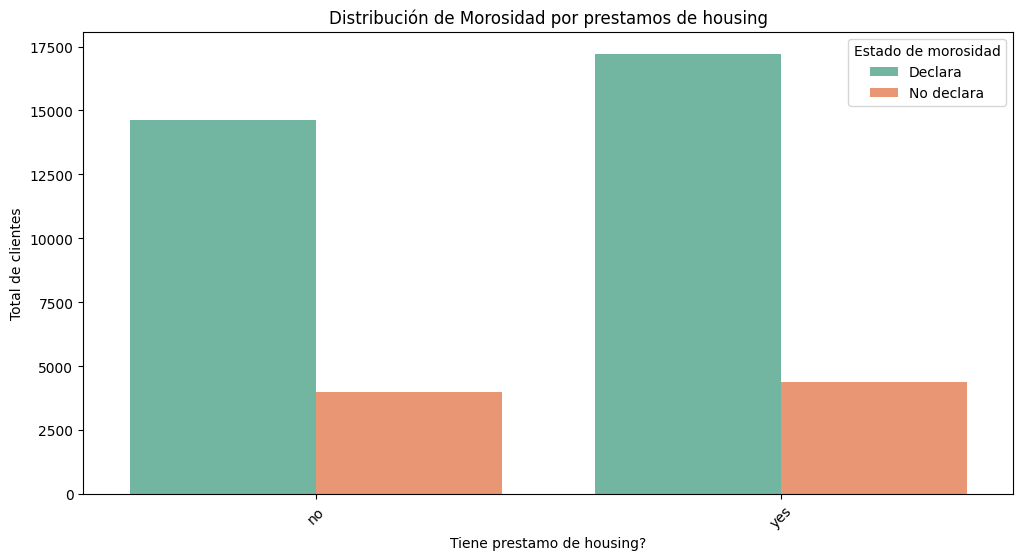

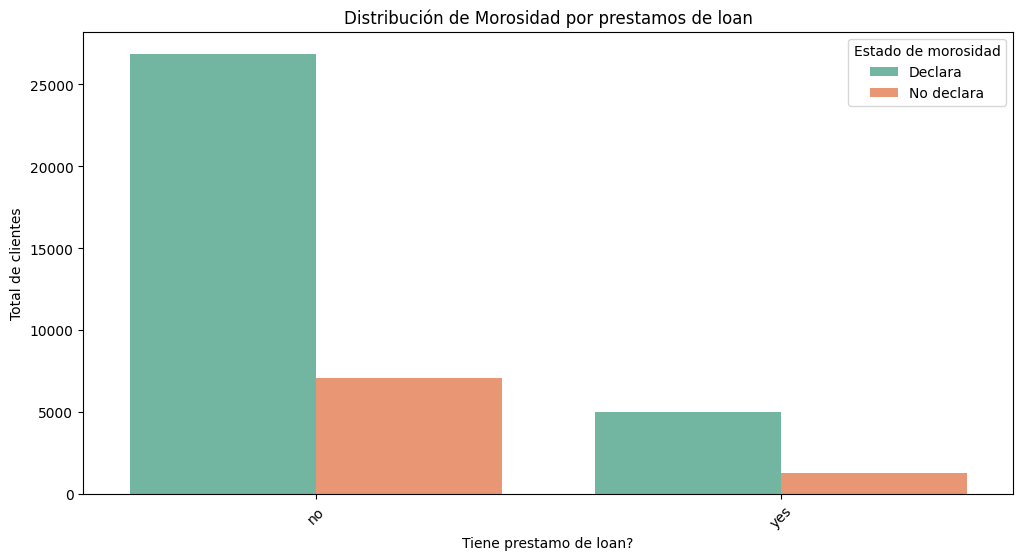

In [80]:
df_analisis = df.copy()
df_analisis['Estado'] = df_analisis['default'].apply(lambda x: 'No declara' if True == pd.isna(x) else 'Declara')
variables = ["housing", "loan"] # Variables que se descubrio que tienen relacion con default(morosidad)
for i in variables:

  plt.figure(figsize=(12, 6))
  sns.countplot(data=df_analisis,
                x=f'{i}',
                hue='Estado',
                palette='Set2')

  plt.title(f'Distribución de Morosidad por prestamos de {i}')
  plt.ylabel("Total de clientes")
  plt.xlabel(f"Tiene prestamo de {i}?")
  plt.xticks(rotation=45)
  plt.legend(title='Estado de morosidad')
  plt.show()
  print("\n")

Se puede observar que existe relacion entre morosidad y loan(prestamo personal), donde la mayoria de personas que no marco un valor en default(morosidad) no declara tener un prestamo, en cuanto a housing(prestamo de vivienda), la cantidad es equitativa, por lo que se deduce que es un MV de tipo MAR, asumiendo que aproximadamente la mitad de los clientes que no marco morosidad , se puede deber al prestamo de vivienda

## Imputacion de variables
* job
* marital
* housing
* loan

Como se menciono antes, los nulos en estas variables son un valor porcentual muy bajo por lo cual se pueden imputar de forma simple sin generar un sesgo muy grande en los modelos

In [81]:
# Se imputan los nulos en las variables, usando la moda de las mismas variables
df["job"] = df["job"].fillna(df["job"].mode()[0])
df["marital"] = df["marital"].fillna(df["marital"].mode()[0])
df["housing"] = df["housing"].fillna(df["housing"].mode()[0])
df["loan"] = df["loan"].fillna(df["loan"].mode()[0])

Verificamos que se imputaron los valores

In [82]:
# Ciclo for para listar MV y su porcentaje en cada variable
for i in range(df.shape[1]):
  n_miss = int(df.iloc[:, i].isnull().sum())
  perc = round(n_miss / df.shape[0] * 100,1)
  if n_miss > 0: # Trae solo las variables con nulos, evita mostrar muchos datos inecesarios
    t = "{0} - {1}  =  Missing: {2} ({3}%)".format(i, df.columns[i], n_miss, perc)
    print(t)

3 - education  =  Missing: 1731 (4.2%)
4 - default  =  Missing: 8597 (20.9%)


In [83]:
df.head(5)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,NaN,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Preparacion de variables para imputacion
(Preparacion para el iterativeImputer)


Se traen las bibliotecas necesarias

In [84]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

# Necesario para activar el iterativeImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor

In [85]:
# Solo se tomnas las variables relacionadas a los clientes, que es donde hay que imputar
df_itera = df[["age", "job", "marital", "education", "default", "housing", "loan"]].copy()

Se codifican las variables categoricas usando OrdinalEncoder para aplicarles un valor numerico que funciona como etiqueta para el iterativeImputer

In [86]:
# Solo hace falta codificar las variables categoricas ya que IterativeImputer necesita que sea un valor numerico
catColums = ['job', 'marital', 'education', 'housing', 'loan', 'default']

# Se codifican con OrdinalEncoder que permite codificar varias columnas,
# No se establece un orden jerarquico, pero hace falta para asignar un numero como etiqueta
catOrdCodifi = OrdinalEncoder(
    handle_unknown='use_encoded_value', # Valores desconocidos(Como nuevos o Nan), quedan en Nan
    unknown_value=np.nan # Los nulos quedan como nulos al codificar
    )

# Se codifican los datos para asignarles un numero a los valores
df_itera[catColums] = catOrdCodifi.fit_transform(df_itera[catColums])

## Imputacion de variables default y education a traves de iterativeImputer
(con ExtraTreesRegressor)

Por que IterativeImputer con ExtraTreeRegressor?
* Preferimos iterativeImputer por sobre otras opciones como knn, esto debido a su capacidad para tratar con datos mas caoticos ya que no es sensible a outliers como knn que calcula distancias, IterativeImputer con ExtraTreesRegressor usa arboles de decisiones que a traves de varias pruebas buscan relaciones entre las columnas para poder imputar los datos

Con las variables default y education ya preparadas, imputamos las variables usando IterativeImputer con ExtraTreesRegressor
* Funciona con arboles de deciciones por lo cual no hace falta escalar las variables numericas
* Hace falta pasar las variables cualitativas a numericas, por eso se utiliza el ordinalEncoder, como se menciono antes, el numero funciona como "etiqueta"

In [87]:
# Se configura IterativeImputer para imputar los valores nulos
# En este caso las variables con nulos son Education y Default
impuNa = IterativeImputer(
    estimator=ExtraTreesRegressor(n_estimators=10, random_state=42), # 10 arboles
    max_iter=10, # 10 iteraciones que hace cambiando los valores nulos
    random_state=42
)

# Se imputan las variables Education y Default
df_imp = impuNa.fit_transform(df_itera)

Creacion de DataFrame con los valores imputados

In [88]:
# Se crea un nuevo dataFrame con las variables ya imputadas pero aun codificadas
df_final_itera = pd.DataFrame(
    df_imp,
    columns=df_itera.columns,
    index=df_itera.index
)

Recuperacion de valores en base al target (Recuperacion de numeros strings de variables categoricas)

In [89]:
# Al ser un modelo de regresion, los valores pueden ser por ejemplo 2.8, se redondean para mantener
# El rango de valores con el que fue codificado, en este caso, numeros enteros, esto mantiene una eiqueta para los nulos que fueron imputados con valores decimales
df_final_itera[catColums] = df_final_itera[catColums].round().astype(int)

# Ahora que los valores ya no son decimales como 2.8, podemos hacer la codificacion inversa y darle
# el valor correspondiente a cada etiqueta(numero) dentro de cada variable
df_final_itera[catColums] = catOrdCodifi.inverse_transform(df_final_itera[catColums])

# Variables ya imputadas
df_final_itera.head(2)

,age,job,marital,education,default,housing,loan
0,56.0,housemaid,married,basic.4y,no,no,no
1,57.0,services,married,high.school,no,no,no


Verificamos que se imputo el valor en la fila 2 de la variable default(mora)

In [90]:
df['default'].iloc[1] # DataFrame original tiene un nulo en la fila 1 en la variable default

nan

In [91]:

df_final_itera['default'].iloc[1] # DataFrame imputado con iterativeImputer ahora tiene un'no' en la fila 1 de la variable default

'no'

In [92]:
df['education'].iloc[7]

nan

In [93]:
df_final_itera['education'].iloc[7]

'basic.6y'

## Resultado de imputacion
(DataSet completo y imputado)

In [94]:
# df original sin las columnas columnas de cliente
df_origi = df.drop(columns=["age", "job", "marital", "education", "default", "housing", "loan"]).copy()
df_Imp = df_final_itera.copy()
df_clean = pd.concat([df_Imp, df_origi], axis=1)
df_clean.head(8)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45.0,services,married,basic.9y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59.0,admin.,married,professional.course,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41.0,blue-collar,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [95]:
for i in range(df_clean.shape[1]):
  n_miss = int(df_clean.iloc[:, i].isnull().sum())
  perc = round(n_miss / df_clean.shape[0] * 100,1)
  if n_miss > 0: # Trae solo las variables con nulos, evita mostrar muchos datos inecesarios
    t = "{0} - {1}  =  Missing: {2} ({3}%)".format(i, df_clean.columns[i], n_miss, perc)
    print(t)

In [96]:
df_clean.isna().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


Ya no hay mas variables con valores Nulos

## Analisis comparativos

Ahora que tenemos el dataSet ya limpio, podemos hacer analisis para comparar como son los resultados con la data limpia vs la data sucia

In [97]:
df_clean.head(2)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Para ver un mejor ejemplo, usaremos la variable "default"(mora), ya que al tener mas del 20% de datos nulos deberia mostrar un mayor cambio

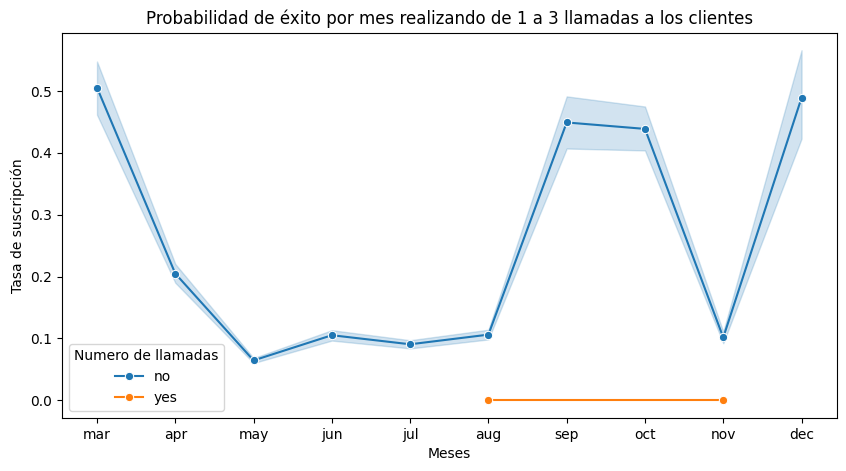

In [98]:
df_analisis = df_clean.copy()

orden_meses = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
df_analisis['month'] = pd.Categorical(df_analisis['month'], categories=orden_meses, ordered=True)

df_analisis['exito_num'] = (df_analisis['y'] == 'yes').astype(int)

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df_analisis,
    x='month',
    y='exito_num',
    marker='o',
    color='green',
    hue='default',
    palette='tab10'
)
plt.title('Probabilidad de éxito por mes realizando de 1 a 3 llamadas a los clientes')
plt.ylabel('Tasa de suscripción')
plt.xlabel("Meses")
plt.legend(title='Numero de llamadas')
plt.show()

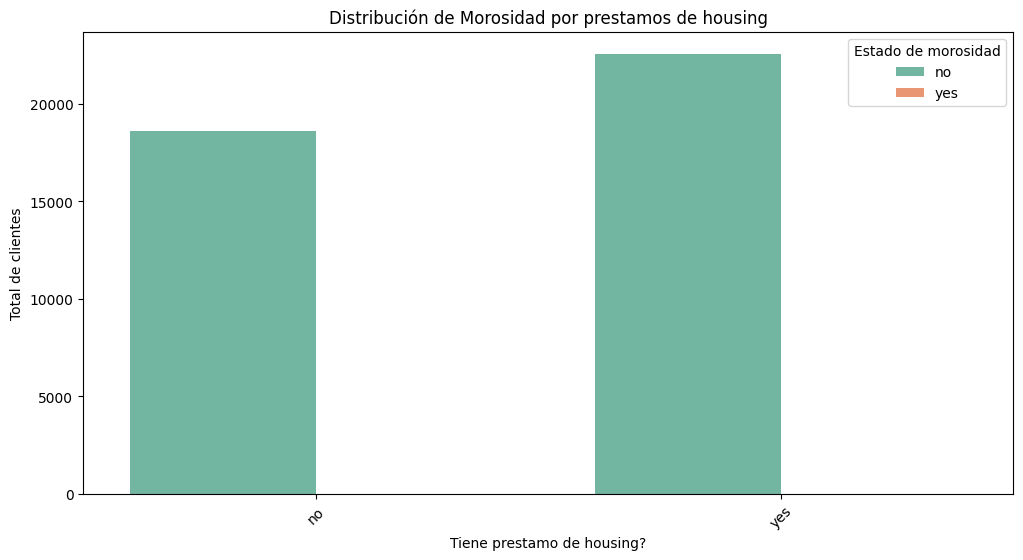

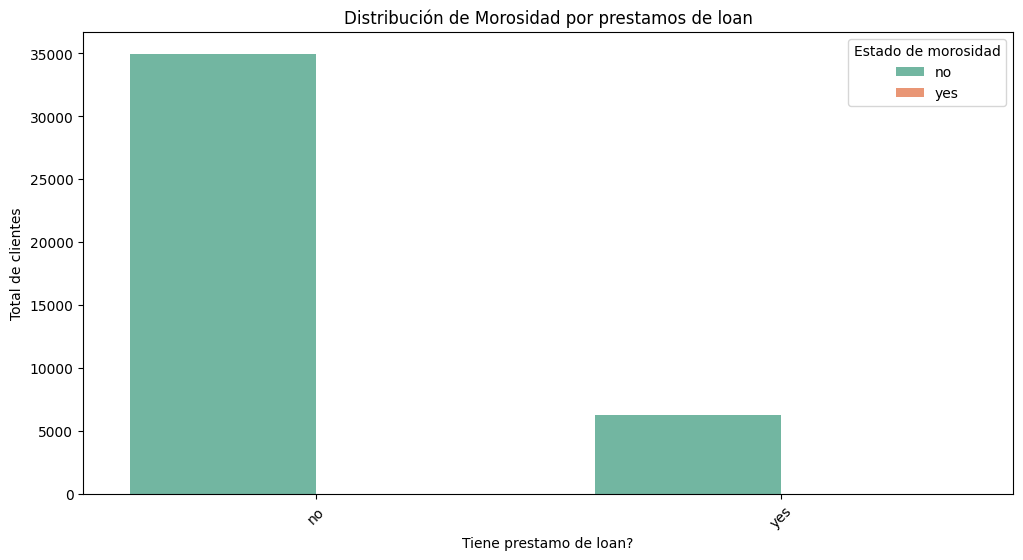

In [99]:
variables = ["housing", "loan"] # Variables que se descubrio que tienen relacion con default(morosidad)
for i in variables:

  plt.figure(figsize=(12, 6))
  sns.countplot(data=df_clean,
                x=f'{i}',
                hue='default',
                palette='Set2')

  plt.title(f'Distribución de Morosidad por prestamos de {i}')
  plt.ylabel("Total de clientes")
  plt.xlabel(f"Tiene prestamo de {i}?")
  plt.xticks(rotation=45)
  plt.legend(title='Estado de morosidad')
  plt.show()
  print("\n")

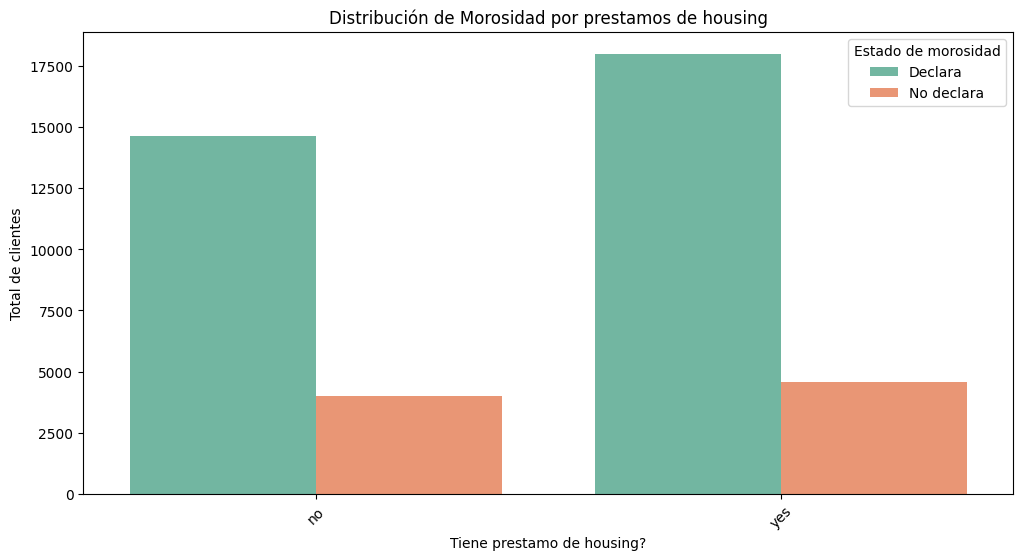

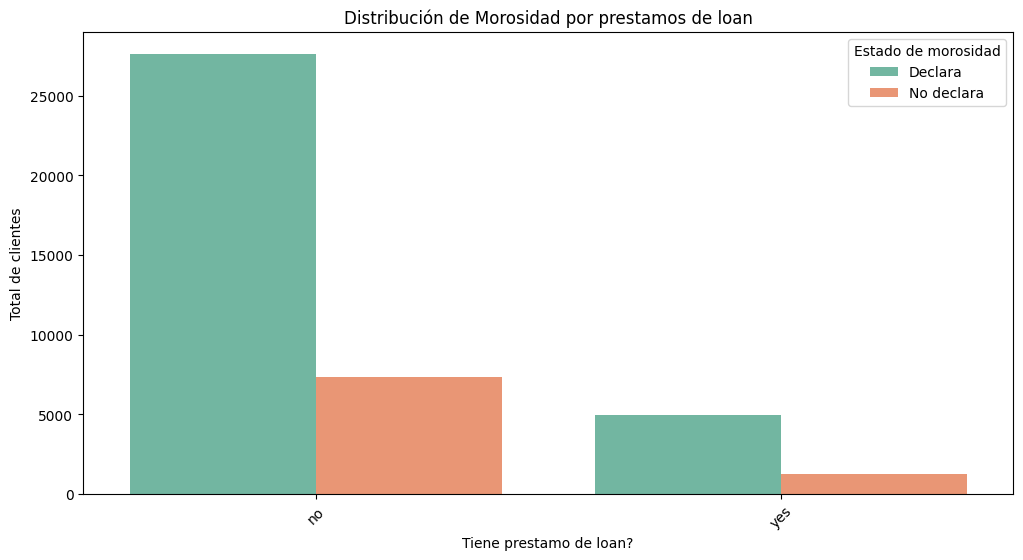

In [100]:
df['Estado'] = df['default'].apply(lambda x: 'No declara' if True == pd.isna(x) else 'Declara')
variables = ["housing", "loan"] # Variables que se descubrio que tienen relacion con default(morosidad)
for i in variables:

  plt.figure(figsize=(12, 6))
  sns.countplot(data=df,
                x=f'{i}',
                hue='Estado',
                palette='Set2')

  plt.title(f'Distribución de Morosidad por prestamos de {i}')
  plt.ylabel("Total de clientes")
  plt.xlabel(f"Tiene prestamo de {i}?")
  plt.xticks(rotation=45)
  plt.legend(title='Estado de morosidad')
  plt.show()
  print("\n")

## Preparando los datos para futuros modelos

Ahora que el dataSet ya esta limpio y se mostraron sus relaciones, se escalaran y codificaran segun el tipo de variable, para su futuro uso en otros modelos

In [101]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

Busquedas de putliers en variables numericas que varian por cliente, asi sabremos si aplicar robustScaler

In [102]:
variNumeri = ['age', 'campaign', 'pdays', 'previous']

for i in variNumeri:
  q1 = df_clean[i].quantile(0.25)
  q3 = df_clean[i].quantile(0.75)
  iqr = q3 - q1 # Rango interquantil
  outMin = q1 - 1.5 * iqr # Outliers menores
  outMax = q3 + 1.5 * iqr # Outliers mayores
  outliers = df_clean[(df_clean[i] < outMin) | (df_clean[i] > outMax)]
  print(f"Variable: {i}")
  print(f"Outliers: {outliers.shape[0]}")
  print("\n")

Variable: age
Outliers: 469


Variable: campaign
Outliers: 2406


Variable: pdays
Outliers: 1515


Variable: previous
Outliers: 5625




Efectivamente hay outliers, por lo cual se aplicaran dichas variables con RobustScaler

In [103]:
df_pipeline = df_clean.copy()

# Variables numericas a escalar con RobustScaler por valores atipicos
robust = ['age', 'campaign', 'pdays', 'previous']

# Se escalan las variables con StandardScaler para ajustar los datos para modelos que requieran normalidad
# No normaliza los datos pero reduce el impacto negativo en procesos que requieren los datos normalizados
standard = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

# Al ser variables categoricas nominales, es decir, sin un orden jerarquico, se utiliza OneHotEncoder
onehot = ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'poutcome']

# Ya que las siguientes variables cualitativas si tienen un orden jerarquico, se utiliza OrdinalEncoder
# para darles un orden , asignandoles valores de 0 a N, en las variables, segun su valor correspondiente
# Educacion tiene un orden jerarquico desde analfabeto a titulo universitario
# Mes tiene el clasico orden jerarquico de los meses del año en este caso faltan 2 meses y es de Marzo a Diciembre
# Dia de la semana, tiene el clasico orden jerarquico de luneas a viernes, no tiene ni sabado ni domingo
ordinal = ['education', 'month', 'day_of_week']

ordEdu = ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
          'high.school', 'professional.course', 'university.degree'] # Orden de education
ordMonth = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'] # Orden de month
ordDay = ['mon', 'tue', 'wed', 'thu', 'fri'] # Orden day_of_week

ordGeneral = [ordEdu, ordMonth, ordDay] # Orden de las variables cualitativas Ordinales

# Creando objeto de ordinalEncoder
ordEncoder = OrdinalEncoder(
    categories=ordGeneral
    )

# Se crea un pipeline con el que transformar todas las columnas
pipeline = ColumnTransformer(transformers=[
  ('robust', RobustScaler(), robust), # Variables escaladas con RobustScaler
  ('oneHot', OneHotEncoder(), onehot), # Variables codificadas con OneHotEncoder
  ('stand', StandardScaler(), standard), # Variables escaladas con StandardScaler
  ('ordinal', ordEncoder, ordinal) # Variables codificadas con OrdinalEncoder
])
X_transf = pipeline.fit_transform(df_pipeline)
print(X_transf)

[[ 1.2        -0.5         0.         ...  1.          2.
   0.        ]
 [ 1.26666667 -0.5         0.         ...  4.          2.
   0.        ]
 [-0.06666667 -0.5         0.         ...  4.          2.
   0.        ]
 ...
 [ 1.2         0.          0.         ...  6.          8.
   4.        ]
 [ 0.4        -0.5         0.         ...  5.          8.
   4.        ]
 [ 2.4         0.5         0.         ...  5.          8.
   4.        ]]


## Referencias

Librerias usadas

In [104]:
# Bibliotecas generales
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Escalado y codificacion de datos
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

# IterativeImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor

El DataSet es :
<br>bank-additional-full, obtenido de la evaluacion 2
<br>El dataSet recopila información de
campañas de marketing realizadas entre mayo de 2008 y noviembre de 2010